In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [149]:
df= pd.read_csv('/content/student.csv')
df

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,23,Male,3rd Year,3.0,0,178,Gemini,NaN,6,...,5,8.1,19.2,8.3,1.9,1.0,10,49.7,1,Low
7996,7997,21,Other,1st Year,3.3,0,63,Claude,Exam Prep,10,...,6,5.7,3.0,5.0,1.3,2.9,5,58.4,1,Medium
7997,7998,24,Male,3rd Year,1.6,0,113,ChatGPT,Coding,5,...,6,4.5,-18.0,5.0,3.5,0.1,9,69.1,1,Medium
7998,7999,22,Female,2nd Year,5.5,0,21,Copilot,Coding,5,...,8,3.4,-19.1,4.7,5.9,0.4,7,49.2,1,Low


In [150]:
df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

In [152]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
grade_level,0
study_hours_per_day,0
uses_ai,0
ai_usage_time_minutes,0
ai_tools_used,1362
ai_usage_purpose,1346
ai_dependency_score,0


In [153]:
df.duplicated().sum()

np.int64(0)

In [154]:
df['ai_tools_used']=df['ai_tools_used'].fillna('No')

In [155]:
df['ai_usage_purpose']=df['ai_usage_purpose'].fillna('No')

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    8000 non-null   object 
 8   ai_usage_purpose                 8000 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

# EDA


<Axes: >

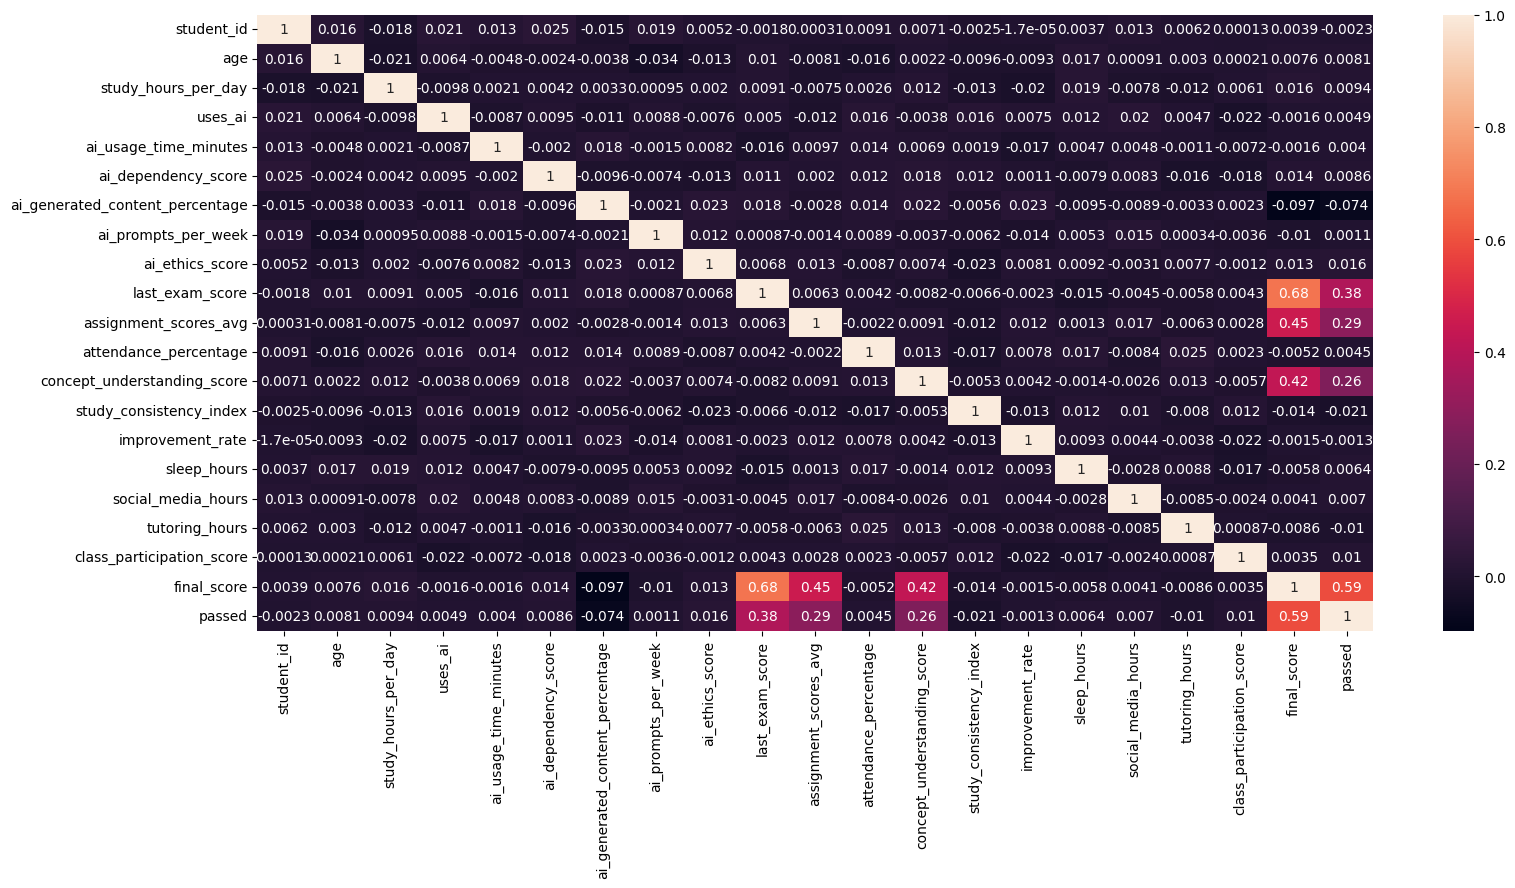

In [157]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(18,8))
sns.heatmap(corr,annot=True)

In [158]:
remove=['student_id','study_hours_per_day','uses_ai','ai_usage_time_minutes','ai_dependency_score','ai_generated_content_percentage','ai_prompts_per_week','ai_ethics_score','attendance_percentage','study_consistency_index','improvement_rate','sleep_hours','social_media_hours','tutoring_hours','class_participation_score','age','final_score','gender']

In [159]:
for k in remove:
  df=df.drop(k, axis=1)

In [160]:
df

,grade_level,ai_tools_used,ai_usage_purpose,last_exam_score,assignment_scores_avg,concept_understanding_score,passed,performance_category
0,1st Year,No,Exam Prep,29,40.9,4,0,Low
1,12th,No,Notes,60,87.2,8,1,Medium
2,3rd Year,Copilot,Doubt Solving,98,77.1,7,1,Medium
3,12th,ChatGPT+Gemini,Notes,67,86.4,5,1,Medium
4,3rd Year,ChatGPT+Gemini,Coding,40,69.4,5,1,Low
...,...,...,...,...,...,...,...,...
7995,3rd Year,Gemini,No,32,73.1,5,1,Low
7996,1st Year,Claude,Exam Prep,74,58.8,6,1,Medium
7997,3rd Year,ChatGPT,Coding,87,42.5,6,1,Medium
7998,2nd Year,Copilot,Coding,28,73.8,8,1,Low


<Axes: >

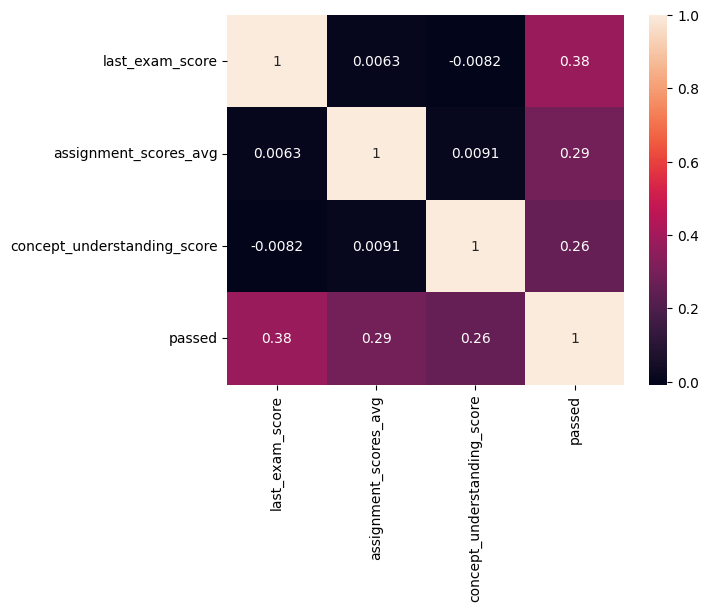

In [161]:
corr=df.corr(numeric_only=True)

sns.heatmap(corr,annot=True)

In [162]:
df['concept_understanding_score'].max()


10

In [163]:
from sklearn.preprocessing import LabelEncoder
import joblib

label_encoders = {}
encode=['grade_level','ai_tools_used','ai_usage_purpose','performance_category']
for i in encode:
  le = LabelEncoder()
  df[i]=le.fit_transform(df[i])
  label_encoders[i] = le
df

,grade_level,ai_tools_used,ai_usage_purpose,last_exam_score,assignment_scores_avg,concept_understanding_score,passed,performance_category
0,3,5,2,29,40.9,4,0,1
1,2,5,5,60,87.2,8,1,2
2,5,3,1,98,77.1,7,1,2
3,2,1,5,67,86.4,5,1,2
4,5,1,0,40,69.4,5,1,1
...,...,...,...,...,...,...,...,...
7995,5,4,4,32,73.1,5,1,1
7996,3,2,2,74,58.8,6,1,2
7997,5,0,0,87,42.5,6,1,2
7998,4,3,0,28,73.8,8,1,1


In [164]:
joblib.dump(label_encoders, 'label_encoders.pkl')
print("Label encoders saved to label_encoders.pkl")

Label encoders saved to label_encoders.pkl


You can download the `label_encoders.pkl` file using the following cell:

In [165]:
from google.colab import files
files.download('label_encoders.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [169]:
x=df.drop('passed',axis=1)
y=df['passed']

In [170]:
x

,grade_level,ai_tools_used,ai_usage_purpose,last_exam_score,assignment_scores_avg,concept_understanding_score,performance_category
0,3,5,2,29,40.9,4,1
1,2,5,5,60,87.2,8,2
2,5,3,1,98,77.1,7,2
3,2,1,5,67,86.4,5,2
4,5,1,0,40,69.4,5,1
...,...,...,...,...,...,...,...
7995,5,4,4,32,73.1,5,1
7996,3,2,2,74,58.8,6,2
7997,5,0,0,87,42.5,6,2
7998,4,3,0,28,73.8,8,1


In [171]:
x=x.astype(int)
x

,grade_level,ai_tools_used,ai_usage_purpose,last_exam_score,assignment_scores_avg,concept_understanding_score,performance_category
0,3,5,2,29,40,4,1
1,2,5,5,60,87,8,2
2,5,3,1,98,77,7,2
3,2,1,5,67,86,5,2
4,5,1,0,40,69,5,1
...,...,...,...,...,...,...,...
7995,5,4,4,32,73,5,1
7996,3,2,2,74,58,6,2
7997,5,0,0,87,42,6,2
7998,4,3,0,28,73,8,1


In [172]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
number=['last_exam_score','assignment_scores_avg','concept_understanding_score']
df[number]=scaler.fit_transform(df[number])
df

,grade_level,ai_tools_used,ai_usage_purpose,last_exam_score,assignment_scores_avg,concept_understanding_score,passed,performance_category
0,3,5,2,-1.316955,-1.209148,-0.512272,0,1
1,2,5,5,0.021535,1.103419,0.867817,1,2
2,5,3,1,1.662263,0.598950,0.522795,1,2
3,2,1,5,0.323774,1.063461,-0.167249,1,2
4,5,1,0,-0.842007,0.214354,-0.167249,1,1
...,...,...,...,...,...,...,...,...
7995,5,4,4,-1.187423,0.399160,-0.167249,1,1
7996,3,2,2,0.626014,-0.315089,0.177773,1,2
7997,5,0,0,1.187316,-1.129232,0.177773,1,2
7998,4,3,0,-1.360132,0.434123,0.867817,1,1


In [173]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [174]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [175]:
models={
    'logistic':LogisticRegression(),
    'xgboost':XGBClassifier(),
    'KNN':KNeighborsClassifier(),
    'SVM':SVC(),
    'naive':GaussianNB(),
    'tree':DecisionTreeClassifier(),
    'Random':RandomForestClassifier()
}

In [176]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [177]:
for name,model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  acc=accuracy_score(y_pred,y_test)
  cm=confusion_matrix(y_pred,y_test)
  cr=classification_report(y_pred,y_test)
  print(f"model:{name}")
  print(acc)
  print(cm)
  print(cr)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


model:logistic
0.945
[[ 122   36]
 [  52 1390]]
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       158
           1       0.97      0.96      0.97      1442

    accuracy                           0.94      1600
   macro avg       0.84      0.87      0.85      1600
weighted avg       0.95      0.94      0.95      1600

model:xgboost
0.930625
[[ 117   54]
 [  57 1372]]
              precision    recall  f1-score   support

           0       0.67      0.68      0.68       171
           1       0.96      0.96      0.96      1429

    accuracy                           0.93      1600
   macro avg       0.82      0.82      0.82      1600
weighted avg       0.93      0.93      0.93      1600

model:KNN
0.92375
[[ 104   52]
 [  70 1374]]
              precision    recall  f1-score   support

           0       0.60      0.67      0.63       156
           1       0.96      0.95      0.96      1444

    accuracy                           

In [178]:
import joblib
joblib.dump(models['logistic'], 'best_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(x.columns.tolist(), 'feature_columns.pkl')

['feature_columns.pkl']

In [179]:
import joblib

try:
    # Load the label_encoders.pkl file
    label_encoders_loaded = joblib.load('label_encoders.pkl')

    print("Loaded LabelEncoders:")
    for col, le in label_encoders_loaded.items():
        print(f"  {col}: Categories = {le.classes_}")
except FileNotFoundError:
    print("Error: The file 'label_encoders.pkl' was not found.")
    print("This file needs to be created and saved in a previous step.")
    print("You need to save the LabelEncoder objects used for categorical features before attempting to load them.")
    label_encoders_loaded = {} # Initialize as empty to prevent further errors if code relies on it

Loaded LabelEncoders:
  grade_level: Categories = ['10th' '11th' '12th' '1st Year' '2nd Year' '3rd Year']
  ai_tools_used: Categories = ['ChatGPT' 'ChatGPT+Gemini' 'Claude' 'Copilot' 'Gemini' 'No']
  ai_usage_purpose: Categories = ['Coding' 'Doubt Solving' 'Exam Prep' 'Homework' 'No' 'Notes']
  performance_category: Categories = ['High' 'Low' 'Medium']
